In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../data/DSA4262 Phone Use Survey.csv')
df_numeric = pd.read_csv('../data/DSA4262 Phone Use Survey.csv')

In [3]:
mapping_phq9 = {
    'Not at all': 0,
    'Several days': 1,
    'More than half the days': 2,
    'Nearly every day': 3
}

phq_cols = df.iloc[:, 35:44].replace(mapping_phq9)
df['PHQ-9 Score'] = phq_cols.sum(axis=1)
df_numeric['PHQ-9 Score'] = phq_cols.sum(axis=1)

mapping_sassv = {
    'Strongly disagree': 1,
    'Disagree': 2,
    'Weakly disagree': 3,
    'Weakly agree': 4,
    'Agree': 5,     
    'Strongly agree': 6
}

sassv_cols = df.iloc[:, 25:35].replace(mapping_sassv)
df['SAS-SV Score'] = sassv_cols.sum(axis=1)
df_numeric['SAS-SV Score'] = sassv_cols.sum(axis=1) 

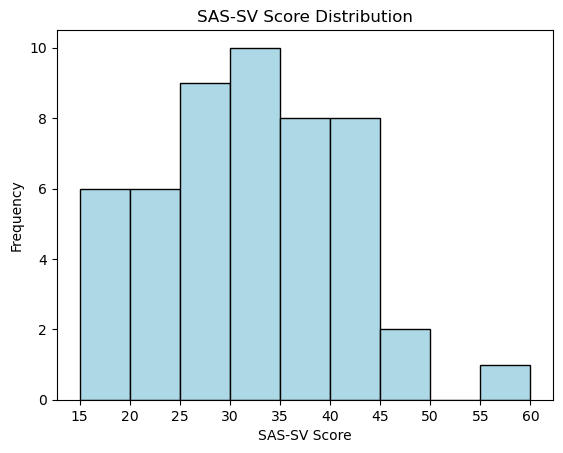

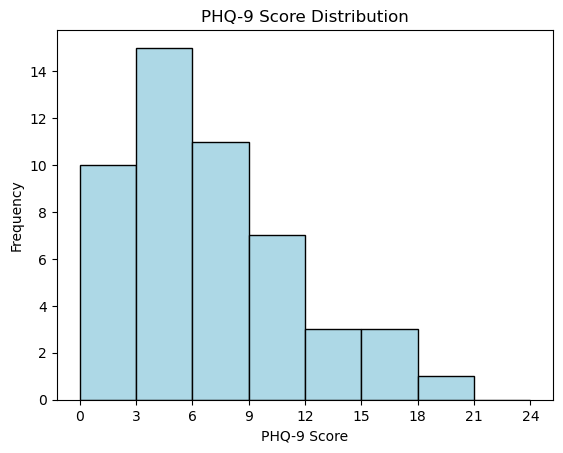

In [4]:
plt.hist(df['SAS-SV Score'], bins=range(15,65,5), edgecolor='black', color='lightblue')
plt.title('SAS-SV Score Distribution')
plt.xticks(range(15,65,5))
plt.xlabel('SAS-SV Score')
plt.ylabel('Frequency')
plt.show()

plt.hist(df['PHQ-9 Score'], bins=range(0,27,3), edgecolor='black', color='lightblue')
plt.title('PHQ-9 Score Distribution')
plt.xticks(range(0,27,3))
plt.xlabel('PHQ-9 Score')
plt.ylabel('Frequency')
plt.show()

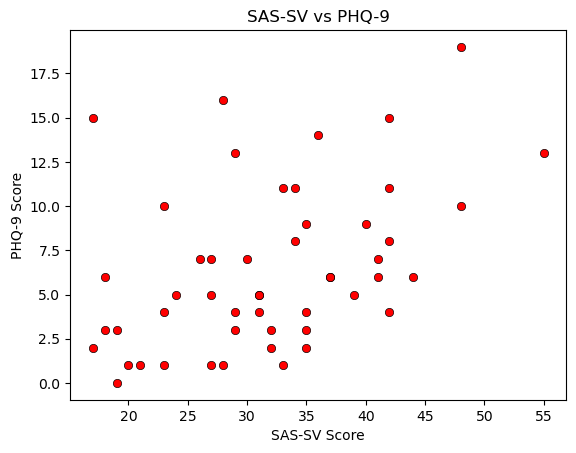

Correlation score between SAS-SV Score and PHQ-9 Score:
0.43126935469428607


In [5]:
sns.scatterplot(x=df['SAS-SV Score'], y=df['PHQ-9 Score'], color = 'red', edgecolor='black')
plt.title('SAS-SV vs PHQ-9')
plt.show()

print("Correlation score between SAS-SV Score and PHQ-9 Score:")
print(df[['SAS-SV Score', 'PHQ-9 Score']].corr().iloc[0,1])

In [6]:
df_numeric.drop(['Timestamp', 'Age', 'Gender', 'Occupational / Educational Status'], axis=1, inplace=True)

freq_map = {
    'Never': 0,
    'Rarely': 1,
    'Sometimes': 2,
    'Often': 3,
    'Always': 4
}

index_4_map = {
    'Less than 2 hours': 0,
    '2 to 4 hours': 1,
    '4 to 6 hours': 2,
    '6 to 8 hours': 3,
    'More than 8 hours': 4
}

index_5_map = {
    'Less than 20': 0,
    '20 to 50': 1,
    '50 to 100': 2,
    'More than 100': 3
}

index_6_map = {
    'Immediately': 0,
    'Within 5 minutes': 1,
    '5 to 30 minutes': 2,
    'More than 30 minutes': 3
}

index_7_map = {
    'Never': 0,
    'Rarely': 1,
    'Sometimes': 2,
    'Often': 3,
    'Almost every night': 4
}

index_8_map = {
    'Before 10pm': 0,
    '10pm to 11pm': 1,
    '11pm to 12am': 2,
    '12am to 1am': 3,
    'After 1am': 4
}

index_10_map = {
    'Less than 30 minutes': 0,
    '30 to 60 minutes': 1,
    '1 to 2 hours': 2,
    '2 to 4 hours': 3,
    'More than 4 hours': 4
}

freq_cols = df.iloc[:, 11:25].columns
df_numeric[freq_cols] = df[freq_cols].replace(freq_map)
df_numeric["On average, how much time did you spend using your smartphone per day in the last 2 weeks?"] = df["On average, how much time did you spend using your smartphone per day in the last 2 weeks?"].replace(index_4_map)
df_numeric["How often do you check your phone in a typical day? (estimate)"] = df["How often do you check your phone in a typical day? (estimate)"].replace(index_5_map)
df_numeric["How soon do you usually check your phone after waking up?"] = df["How soon do you usually check your phone after waking up?"].replace(index_6_map)
df_numeric["How often do you use your phone after 11 PM?"] = df["How often do you use your phone after 11 PM?"].replace(index_7_map)
df_numeric["When do you usually stop using your phone at night?"] = df["When do you usually stop using your phone at night?"].replace(index_8_map)
df_numeric["Approximately how much time per day do you spend on social media apps?"] = df["Approximately how much time per day do you spend on social media apps?"].replace(index_10_map)   

In [7]:
for col in df_numeric.columns:
    if col != 'PHQ-9 Score' and col != 'SAS-SV Score' and df_numeric[col].dtype in [np.int64, np.float64]:
        print(f"Correlation score between {col} and PHQ-9 Score: {df_numeric[col].corr(df_numeric['PHQ-9 Score'])}")

Correlation score between On average, how much time did you spend using your smartphone per day in the last 2 weeks? and PHQ-9 Score: 0.2034410869053224
Correlation score between How often do you check your phone in a typical day? (estimate) and PHQ-9 Score: 0.1100330377004939
Correlation score between How soon do you usually check your phone after waking up? and PHQ-9 Score: -0.14014045566928596
Correlation score between How often do you use your phone after 11 PM? and PHQ-9 Score: 0.26363261659498083
Correlation score between When do you usually stop using your phone at night? and PHQ-9 Score: 0.0581864308152816
Correlation score between Approximately how much time per day do you spend on social media apps? and PHQ-9 Score: 0.3355324211208847
Correlation score between I use my phone during meals. and PHQ-9 Score: 0.12570196197898992
Correlation score between I use my phone during lectures, meetings, or work. and PHQ-9 Score: 0.21818115730316334
Correlation score between I check my ph

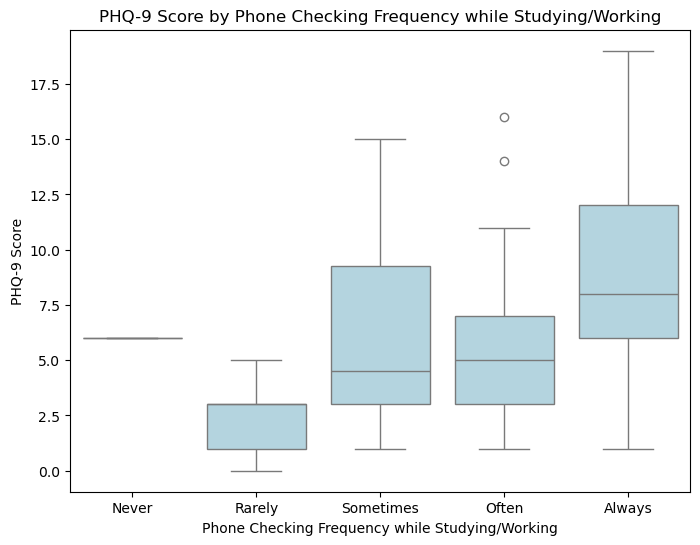

In [8]:
order = ['Never', 'Rarely', 'Sometimes', 'Often', 'Always']
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['I check my phone while studying or working on tasks.'], y=df['PHQ-9 Score'], order=order, color='lightblue')
plt.title('PHQ-9 Score by Phone Checking Frequency while Studying/Working')
plt.xlabel('Phone Checking Frequency while Studying/Working')
plt.ylabel('PHQ-9 Score')
plt.show()

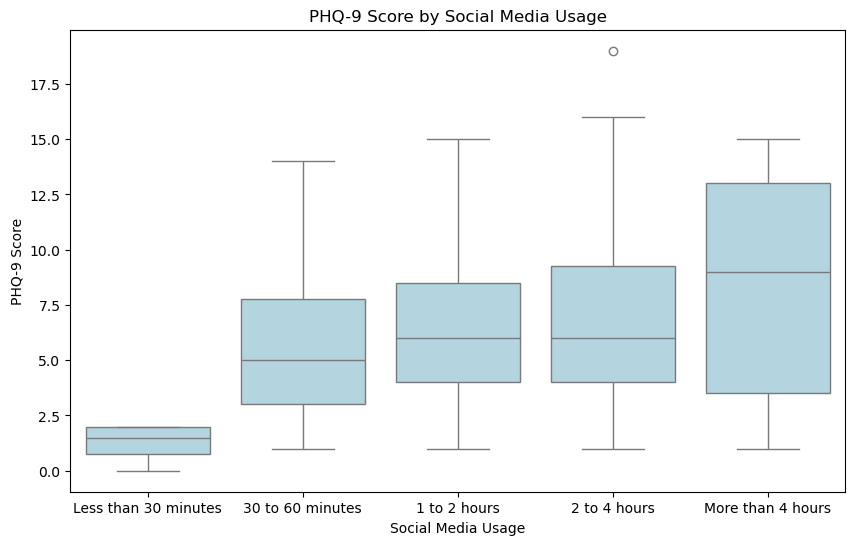

In [9]:
order = ['Less than 30 minutes', '30 to 60 minutes', '1 to 2 hours', '2 to 4 hours', 'More than 4 hours']
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Approximately how much time per day do you spend on social media apps?'], y=df['PHQ-9 Score'], order=order, color='lightblue')
plt.title('PHQ-9 Score by Social Media Usage')
plt.xlabel('Social Media Usage')
plt.ylabel('PHQ-9 Score')
plt.show()

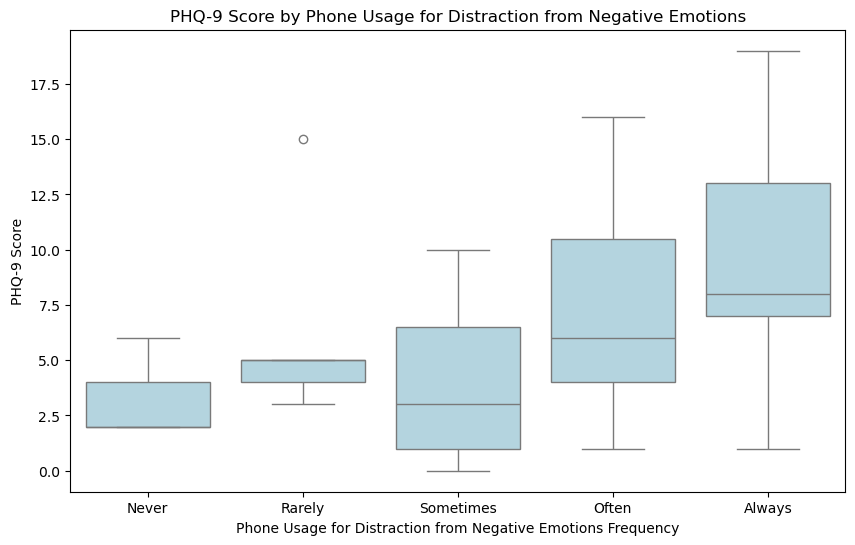

In [10]:
order = ['Never', 'Rarely', 'Sometimes', 'Often', 'Always']
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['I use my phone to distract myself from negative emotions.'], y=df['PHQ-9 Score'], order=order, color='lightblue')
plt.title('PHQ-9 Score by Phone Usage for Distraction from Negative Emotions')
plt.xlabel('Phone Usage for Distraction from Negative Emotions Frequency')
plt.ylabel('PHQ-9 Score')
plt.show()

In [11]:
df_numeric["PHQ-9 Group"] = df_numeric['PHQ-9 Score'].apply(lambda x: 'Non-depressive range' if x < 10 else 'Depressive-threshold range')

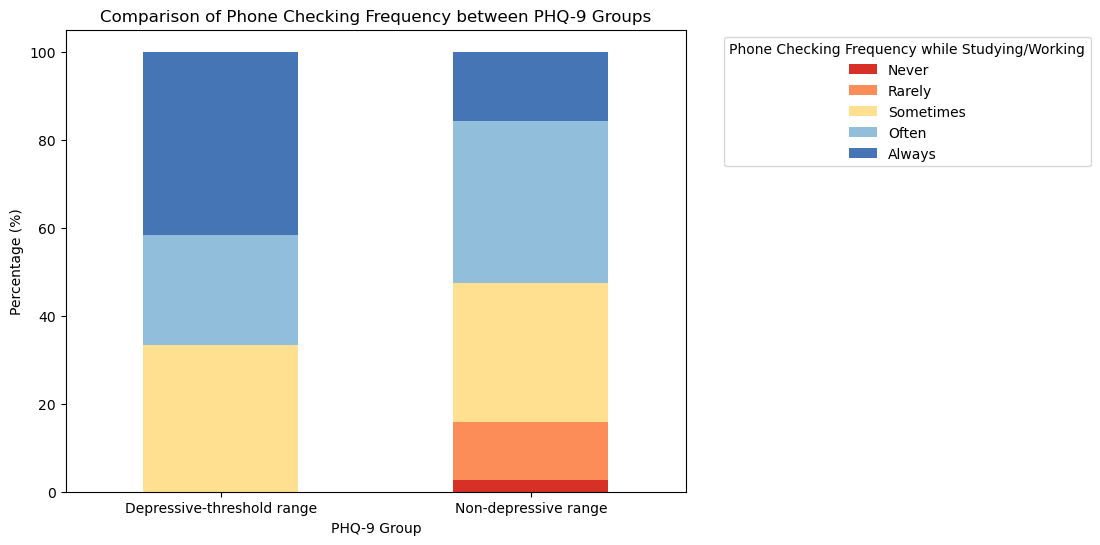

In [12]:
ct = pd.crosstab(
    df_numeric['PHQ-9 Group'],
    df['I check my phone while studying or working on tasks.'], 
    normalize='index'
) * 100

order = ['Never', 'Rarely', 'Sometimes', 'Often', 'Always']
ct = ct[order]
colors = ['#d73027', '#fc8d59', '#fee090', '#91bfdb', '#4575b4']
ct.plot(
    kind='bar',
    stacked=True,
    color=colors,
    figsize=(8,6)
)

plt.xticks(rotation=0)
plt.ylabel('Percentage (%)')
plt.title('Comparison of Phone Checking Frequency between PHQ-9 Groups')
plt.legend(title='Phone Checking Frequency while Studying/Working', bbox_to_anchor=(1.05, 1))
plt.show()

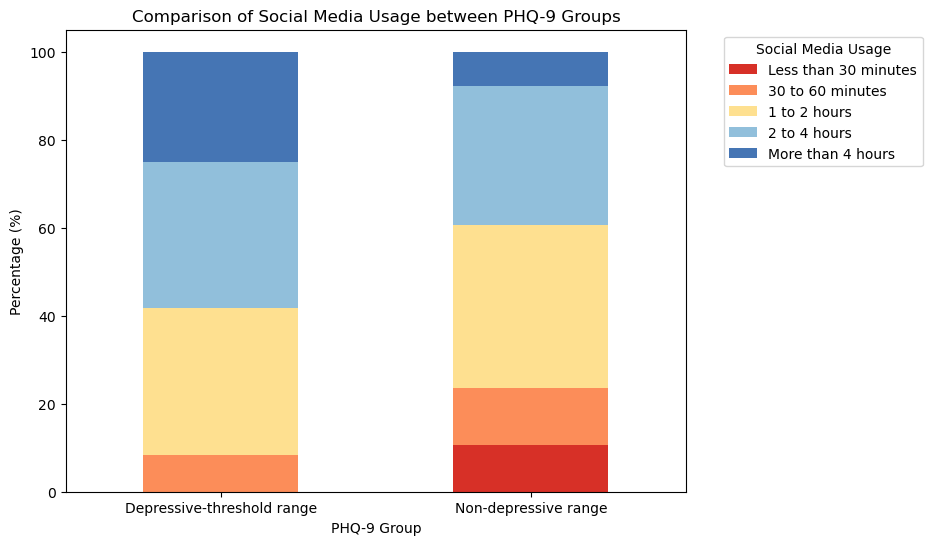

In [13]:
ct1 = pd.crosstab(
    df_numeric['PHQ-9 Group'],
    df['Approximately how much time per day do you spend on social media apps?'], 
    normalize='index'
) * 100

order = ['Less than 30 minutes', '30 to 60 minutes', '1 to 2 hours', '2 to 4 hours', 'More than 4 hours']
ct1 = ct1[order]
colors = ['#d73027', '#fc8d59', '#fee090', '#91bfdb', '#4575b4']
ct1.plot(
    kind='bar',
    stacked=True,
    color=colors,
    figsize=(8,6)
)

plt.xticks(rotation=0)
plt.ylabel('Percentage (%)')
plt.title('Comparison of Social Media Usage between PHQ-9 Groups')
plt.legend(title='Social Media Usage', bbox_to_anchor=(1.05, 1))
plt.show()

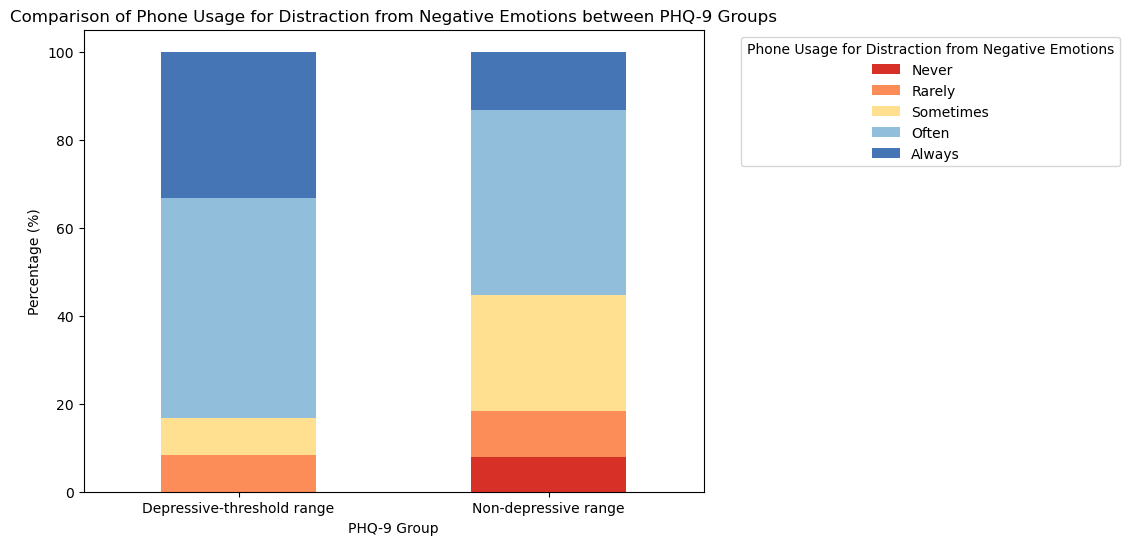

In [14]:
ct2 = pd.crosstab(
    df_numeric['PHQ-9 Group'],
    df['I use my phone to distract myself from negative emotions.'], 
    normalize='index'
) * 100

order = ['Never', 'Rarely', 'Sometimes', 'Often', 'Always']
ct2 = ct2[order]
colors = ['#d73027', '#fc8d59', '#fee090', '#91bfdb', '#4575b4']
ct2.plot(
    kind='bar',
    stacked=True,
    color=colors,
    figsize=(8,6)
)

plt.xticks(rotation=0)
plt.ylabel('Percentage (%)')
plt.title('Comparison of Phone Usage for Distraction from Negative Emotions between PHQ-9 Groups')
plt.legend(title='Phone Usage for Distraction from Negative Emotions', bbox_to_anchor=(1.05, 1))
plt.show()